# Week 3: Diagnostic Labour Market Analysis

## Objective

The objective of Week 3 is to perform diagnostic labour market analysis using the cleaned Government of Canada Job Bank dataset. This stage focuses on identifying employment patterns, occupation demand trends, and regional labour market characteristics to support future feature engineering and predictive modelling activities.

Occupations with sufficient numbers of job postings are selected to ensure reliable descriptive analysis and reduce the impact of sparse observations. Provinces and territories are aggregated into broader Canadian regions to enable meaningful regional comparisons while reducing data sparsity.

The analysis provides the foundation for later stages of the project, including occupation recommendation, skill-gap analysis, and predictive modelling.

In [359]:

# Import Libraries and Configure Display Settings


from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Display numerical values with two decimal places
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [360]:
# Define processed dataset path

DATA_PATH = (
    Path("..")
    / "Data"
    / "Processed"
    / "job_bank_preliminary_clean.csv"
)

# Load cleaned Job Bank dataset

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset Shape: (55091, 66)


,posting_id,job_title,original_job_title,noc_2016_code,noc_2016_name,noc_2021_code,noc_2021_name,external_indicator,posting_date,vacancy_count,official_language,education_level,experience_level,government_type,placement_agency,naics,province,city,work_location_postal_code,economic__region,various_location,employment_type,employment_term,employment_term_start_date,employment_term_end_date,employment_term_oncall,employment_term_overtime,employment_term_day,employment_term_evening,employment_term_shift,employment_term_weekend,employment_term_night,employment_term_telework,employment_term_early,employment_term_flex,employment_term_morning,employment_term_tbd,salary_condition_detail,salary_period,salary_minimum,salary_maximum,salary_condition_collective,salary_condition_bonus,salary_condition_disability,salary_condition_gratuity,salary_condition_medical,salary_condition_mileage,salary_condition_piecework,salary_condition_commission,salary_condition_resp,salary_condition_dental,salary_condition_group_insurance,salary_condition_life_insurance,salary_condition_pension,salary_condition_rrsp,condition_vision_care,salary_condition_other_benefits,commission_per,commission_type,hours_per,hours_minimum,hours_maximum,work_hours,work_hours_from_time,work_hours_to_time,salary_average
0,15645194,Facilities and Fleet Maintenance Support,NaN,NaN,NaN,NaN,NaN,1,2026-06-17,1,English,NaN,NaN,NaN,NaN,NaN,Alberta,NaN,NaN,NaN,No,Full time,Permanent employment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$29.20 hourly,Hour,29.20,29.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,29.20
1,15675531,sales associate,Part Time Sales Associate-SoftMoc ShoeRack Cro...,6421.00,Retail salespersons,64100.00,Retail salespersons and visual merchandisers,1,2026-06-29,1,English,NaN,NaN,NaN,NaN,NaN,Alberta,NaN,NaN,NaN,No,Part time,Permanent employment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$16.00 to $16.50 hourly,Hour,16.00,16.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,16.25
2,15597307,"testing, adjusting and balancing (tab) technic...",HVAC R & Gasfitter Journeymen Apprentice (Leve...,2232.00,Mechanical engineering technologists and techn...,11201.00,Professional occupations in business managemen...,1,2026-06-01,1,*No data,NaN,NaN,NaN,NaN,NaN,British Columbia,NaN,NaN,NaN,No,Full time,Permanent employment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$45.00 to $55.00 hourly,Hour,45.00,55.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,50.00
3,15621351,"chartered professional accountant, chartered a...",NaN,1111.00,Financial auditors and accountants,11100.00,Financial auditors and accountants,0,2026-06-09,1,English,Master's degree,5 years or more,Not a government entity,No,Retail trade,British Columbia,NaN,NaN,NaN,No,Part time,Permanent employment,NaN,NaN,No,No,Yes,No,No,No,No,No,No,No,No,No,$50.00 to $80.00 hourly (to be negotiated),Hour,50.00,80.00,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,NaN,Week,4.00,10.00,No,NaN,NaN,65.00
4,15629538,refrigeration technician,NaN,7313.00,Refrigeration and air conditioning mechanics,72402.00,"Heating, refrigeration and air conditioning me...",1,2026-06-11,1,English,NaN,NaN,NaN,NaN,NaN,British Columbia,NaN,NaN,NaN,No,Full time,Permanent employment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$25.00 to $58.00 hourly,Hour,25.00,58.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,41.50


In [361]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55091 entries, 0 to 55090
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   posting_id                        55091 non-null  int64  
 1   job_title                         55091 non-null  object 
 2   original_job_title                21354 non-null  object 
 3   noc_2016_code                     54716 non-null  float64
 4   noc_2016_name                     54716 non-null  object 
 5   noc_2021_code                     54721 non-null  float64
 6   noc_2021_name                     54721 non-null  object 
 7   external_indicator                55091 non-null  int64  
 8   posting_date                      55091 non-null  object 
 9   vacancy_count                     55091 non-null  int64  
 10  official_language                 55091 non-null  object 
 11  education_level                   21979 non-null  object 
 12  expe

In [362]:
df.describe(include="all")

,posting_id,job_title,original_job_title,noc_2016_code,noc_2016_name,noc_2021_code,noc_2021_name,external_indicator,posting_date,vacancy_count,official_language,education_level,experience_level,government_type,placement_agency,naics,province,city,work_location_postal_code,economic__region,various_location,employment_type,employment_term,employment_term_start_date,employment_term_end_date,employment_term_oncall,employment_term_overtime,employment_term_day,employment_term_evening,employment_term_shift,employment_term_weekend,employment_term_night,employment_term_telework,employment_term_early,employment_term_flex,employment_term_morning,employment_term_tbd,salary_condition_detail,salary_period,salary_minimum,salary_maximum,salary_condition_collective,salary_condition_bonus,salary_condition_disability,salary_condition_gratuity,salary_condition_medical,salary_condition_mileage,salary_condition_piecework,salary_condition_commission,salary_condition_resp,salary_condition_dental,salary_condition_group_insurance,salary_condition_life_insurance,salary_condition_pension,salary_condition_rrsp,condition_vision_care,salary_condition_other_benefits,commission_per,commission_type,hours_per,hours_minimum,hours_maximum,work_hours,work_hours_from_time,work_hours_to_time,salary_average
count,55091.00,55091,21354,54716.00,54716,54721.00,54721,55091.00,55091,55091.00,55091,21979,21979,21722,21979,21979,55091,54682,25596,54682,55091,53059,42511,5980,431,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,55077,54976,55076.00,55076.00,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,197,197,21979,25007.00,25007.00,55091,882,882,55076.00
unique,NaN,6788,12047,NaN,483,NaN,500,NaN,30,NaN,5,11,7,4,2,26,13,2662,15677,76,1,3,4,228,211,2,2,2,2,2,2,2,1,2,2,2,2,10687,6,NaN,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,5,2,4,NaN,NaN,2,45,46,NaN
top,NaN,cook,Teacher Placement Process Positions,NaN,Cooks,NaN,Cooks,NaN,2026-06-04,NaN,English,Secondary (high) school graduation certificate,1 year to less than 2 years,Not a government entity,No,Accommodation and food services,Ontario,Toronto,V0E2S0,Toronto Region,No,Full time,Permanent employment,2026/08/31,2027/11/26,No,No,Yes,No,No,No,No,No,No,No,No,No,$20.00 hourly,Hour,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,sale,Amount,Week,NaN,NaN,No,08:00,17:00,NaN
freq,NaN,1263,405,NaN,2525,NaN,2525,NaN,3386,NaN,23471,10232,6107,21516,21902,4689,16491,2022,46,7445,55091,45139,34138,492,35,20151,18682,13214,13545,17932,13643,18114,21979,16754,17946,12660,20543,1493,45710,NaN,NaN,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,21979,174,114,21061,NaN,NaN,54209,260,234,NaN
mean,15638474.89,NaN,NaN,4897.73,NaN,52082.88,NaN,0.60,NaN,1.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,374063.15,377577.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.10,42.66,NaN,NaN,NaN,375820.10
std,25221.10,NaN,NaN,2588.39,NaN,23225.90,NaN,0.49,NaN,5.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50005427.48,50005412.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.23,68.14,NaN,NaN,NaN,50005418.93
min,15594396.00,NaN,NaN,11.00,NaN,10.00,NaN,0.00,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01,0.01,NaN,NaN,NaN,0.40
25%,15616539.50,NaN,NaN,2253.00,NaN,32120.00,NaN,0.00,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.50,21.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.00,35.00,NaN,NaN,NaN,20.50
50%,15638901.00,NaN,NaN,6311.00,NaN,62100.00,NaN,1.00,NaN,1

In [363]:
from IPython.display import display

print("Missing Value Summary")

missing_summary = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_summary)

Missing Value Summary


commission_per              54894
commission_type             54894
employment_term_end_date    54660
work_hours_to_time          54209
work_hours_from_time        54209
                            ...  
vacancy_count                   0
work_hours                      0
posting_date                    0
external_indicator              0
posting_id                      0
Length: 66, dtype: int64

In [364]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [365]:
# Occupation-Level Labour Market Summary
# Group job postings by occupation and calculate demand metrics


# Count number of job postings and total vacancies for each occupation
occupation_counts = (
    df.groupby(["job_title","noc_2021_code","noc_2021_name"])
      .agg(
          Posting_Count=("posting_id","count"),
          Vacancy_Count=("vacancy_count","sum")
      )
      .sort_values("Posting_Count", ascending=False)
      .reset_index()
)

# Display top 30 occupations based on posting volume
occupation_counts.head(30)

,job_title,noc_2021_code,noc_2021_name,Posting_Count,Vacancy_Count
0,cook,63200.00,Cooks,1263,2233
1,food service supervisor,62020.00,Food service supervisors,750,1716
2,line cook,63200.00,Cooks,642,818
3,administrative assistant,13110.00,Administrative assistants,580,616
4,continuing care assistant,33102.00,"Nurse aides, orderlies and patient service ass...",545,640
5,carpenter,72310.00,Carpenters,486,851
6,restaurant manager,60030.00,Restaurant and food service managers,465,560
7,retail sales associate,64100.00,Retail salespersons and visual merchandisers,459,519
8,"driver, truck",73300.00,Transport truck drivers,425,583
9,cashier,65100.00,Cashiers,410,505


## Selected Occupations for Labour Market Analysis

In [367]:

# Define occupation list for diagnostic analysis and comparison


selected_occupations = [

    "software developer",
    "information technology (it) analyst",

    "administrative assistant",
    "bookkeeper",
    "office administrator",
    "office manager",

    "restaurant manager",
    "food service supervisor",

    "retail sales associate",
    "inside sales representative",

    "driver, truck",
    "delivery driver",

    "secondary school teacher",

    "continuing care assistant",

    "licensed practical nurse (l.p.n.)"

]

In [368]:
# Standardize Job Titles
# Remove extra spaces and convert titles to lowercase
# for consistent occupation matching


df["job_title"] = (
    df["job_title"]
      .str.strip()
      .str.lower()
)

In [369]:
# Filter dataset to selected occupations

df_selected = df[
    df["job_title"].str.lower().isin(selected_occupations)
].copy()

print(df_selected.shape)

df_selected["job_title"].value_counts()

(5629, 66)


job_title
food service supervisor                752
administrative assistant               583
continuing care assistant              545
restaurant manager                     465
retail sales associate                 460
driver, truck                          425
delivery driver                        400
secondary school teacher               394
licensed practical nurse (l.p.n.)      325
software developer                     294
information technology (it) analyst    253
office administrator                   221
inside sales representative            215
bookkeeper                             196
office manager                         101
Name: count, dtype: int64

In [370]:
# Display filtered dataset size

print("Selected dataset shape:")
print("Rows:", df_selected.shape[0])
print("Columns:", df_selected.shape[1])

# Display number of postings by selected occupation

print("\nJob postings by selected occupation:")
df_selected["job_title"].value_counts()

Selected dataset shape:
Rows: 5629
Columns: 66

Job postings by selected occupation:


job_title
food service supervisor                752
administrative assistant               583
continuing care assistant              545
restaurant manager                     465
retail sales associate                 460
driver, truck                          425
delivery driver                        400
secondary school teacher               394
licensed practical nurse (l.p.n.)      325
software developer                     294
information technology (it) analyst    253
office administrator                   221
inside sales representative            215
bookkeeper                             196
office manager                         101
Name: count, dtype: int64

## Occupation Selection

Occupations were selected based on the number of available job postings.

Occupations with higher posting counts were retained to ensure sufficient observations for reliable descriptive analysis and to support predictive machine learning models in later project stages.

The selected occupations represent technology, business, administration, management, sales, healthcare, education, and transportation occupations, providing a balanced representation of the Canadian labour market.

## Aggregate Provinces into Canadian Regions

In [373]:
# Map Provinces and Territories to Canadian Regions
# Aggregate geographic data to support regional labour market analysis


region_map = {

    "Newfoundland and Labrador": "Atlantic",
    "Prince Edward Island": "Atlantic",
    "Nova Scotia": "Atlantic",
    "New Brunswick": "Atlantic",

    "Quebec": "Quebec",
    "Québec": "Quebec",

    "Ontario": "Ontario",

    "Alberta": "Prairies",
    "Saskatchewan": "Prairies",
    "Manitoba": "Prairies",

    "British Columbia": "British Columbia"

}

# Create regional classification column

df_selected["region"] = df_selected["province"].map(region_map)

In [374]:
# Remove records where region could not be assigned

df_selected = df_selected[
    df_selected["region"].notna()
]

## Check Regional Distribution

In [376]:
# Regional Distribution of Selected Occupations
# Count job postings by Canadian region

df_selected["region"].value_counts()

region
Prairies            1890
Ontario             1387
British Columbia     971
Atlantic             807
Quebec               555
Name: count, dtype: int64

## Interpretation

The selected occupations were distributed across five Canadian regions after aggregating provinces. The Prairies recorded the highest number of job postings (1,890), followed by Ontario (1,387) and British Columbia (971). Atlantic Canada accounted for 807 postings, while Quebec had the fewest among the selected regions with 555 postings. This regional aggregation reduced data sparsity and provided a clearer comparison of labour demand across broader geographic areas.

## Occupation Demand Analysis

In [379]:
# Calculate posting volume and vacancy demand metrics
# for selected occupations

occupation_summary = (
    df_selected
    .groupby("job_title")
    .agg(
        Posting_Count=("posting_id","count"),
        Vacancy_Count=("vacancy_count","sum"),
        Average_Vacancies=("vacancy_count","mean"),
        Median_Vacancies=("vacancy_count","median")
    )
    .sort_values("Posting_Count",ascending=False)
)

# Display occupation demand summary
occupation_summary

,Posting_Count,Vacancy_Count,Average_Vacancies,Median_Vacancies
job_title,,,,
food service supervisor,748,1718,2.30,2.00
administrative assistant,581,617,1.06,1.00
continuing care assistant,545,640,1.17,1.00
restaurant manager,463,558,1.21,1.00
retail sales associate,456,516,1.13,1.00
"driver, truck",424,582,1.37,1.00
delivery driver,397,408,1.03,1.00
secondary school teacher,394,395,1.00,1.00
licensed practical nurse (l.p.n.),325,334,1.03,1.00


### Occupation Demand Analysis

The selected occupations were analyzed to understand labour demand based on the number of job postings and vacancies.

Food Service Supervisor recorded the highest number of postings among the selected occupations, followed by Administrative Assistant and Continuing Care Assistant.

Software Developer and Information Technology (IT) Analyst also showed moderate labour demand, supporting their inclusion in the analysis despite representing more specialized occupations.

The selected occupations provide sufficient observations for descriptive statistical analysis and prepare the dataset for future predictive modelling activities.

## Occupation Demand Chart

<Figure size 1000x700 with 0 Axes>

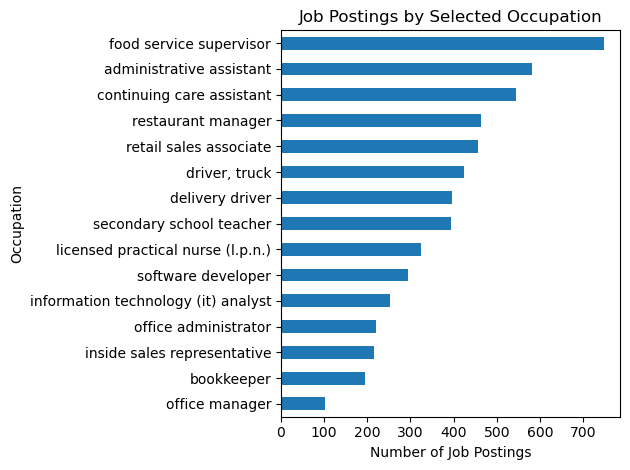

In [382]:
# Occupation Demand Visualization
# Display number of job postings by selected occupation

plt.figure(figsize=(10,7))

occupation_summary.sort_values("Posting_Count").plot(
    kind="barh",
    y="Posting_Count",
    legend=False
)

plt.title("Job Postings by Selected Occupation")
plt.xlabel("Number of Job Postings")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

## Regional Summary

In [384]:
# Regional Labour Market Summary
# Calculate job posting and vacancy demand by region

region_summary = (
    df_selected
    .groupby("region")
    .agg(
        Posting_Count=("posting_id", "count"),
        Vacancy_Count=("vacancy_count", "sum"),
        Average_Vacancies=("vacancy_count", "mean")
    )
    .sort_values("Posting_Count", ascending=False)
)

# Display regional demand summary
region_summary

,Posting_Count,Vacancy_Count,Average_Vacancies
region,,,
Prairies,1890,2262,1.20
Ontario,1387,1662,1.20
British Columbia,971,1437,1.48
Atlantic,807,1032,1.28
Quebec,555,704,1.27


## Regional Demand Chart

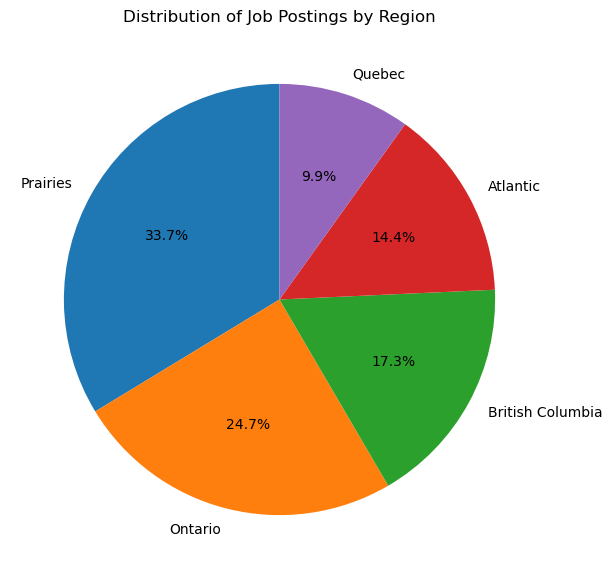

In [386]:
# Regional Demand Visualization
# Show percentage distribution of selected job postings
# across Canadian regions

plt.figure(figsize=(7,7))

plt.pie(
    region_summary["Posting_Count"],
    labels=region_summary.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Job Postings by Region")
plt.show()

### Regional Analysis

The Prairies accounted for the largest share of job postings among the selected occupations, followed by Ontario and British Columbia.

Aggregating provinces into broader Canadian regions reduced geographic data sparsity and enabled clearer comparison of labour demand patterns within the selected occupation sample.

## Vacancy Distribution by Region

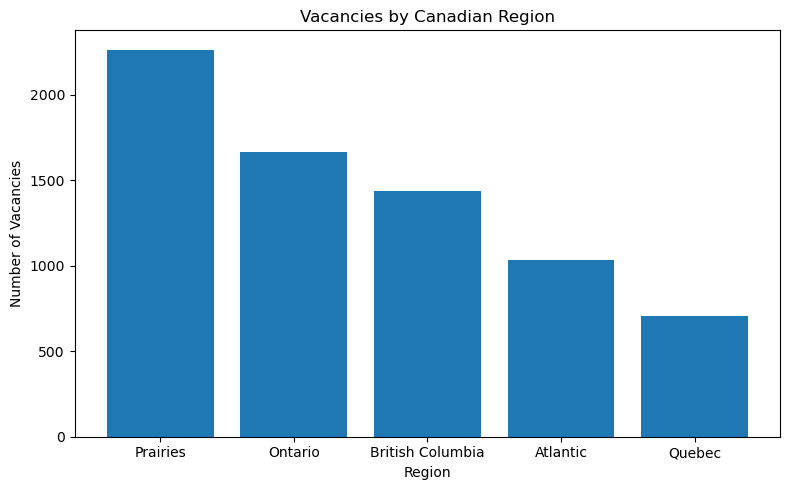

In [389]:
# Regional Vacancy Visualization
# Compare total advertised vacancies across Canadian regions

plt.figure(figsize=(8,5))

plt.bar(
    region_summary.index,
    region_summary["Vacancy_Count"]
)

plt.title("Vacancies by Canadian Region")
plt.xlabel("Region")
plt.ylabel("Number of Vacancies")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Provinces with Highest Job Posting Demand

In [391]:
# Province-Level Occupation Demand Matrix
# Count job postings by province and occupation

province_occ = (
    df_selected
    .groupby(["province","job_title"])
    .size()
    .unstack(fill_value=0)
)

province_occ

job_title,administrative assistant,bookkeeper,continuing care assistant,delivery driver,"driver, truck",food service supervisor,information technology (it) analyst,inside sales representative,licensed practical nurse (l.p.n.),office administrator,office manager,restaurant manager,retail sales associate,secondary school teacher,software developer
province,,,,,,,,,,,,,,,
Alberta,59,28,0,43,39,185,7,30,1,41,24,81,63,0,157
British Columbia,107,56,0,95,43,243,41,46,3,45,37,157,81,2,15
Manitoba,17,7,0,13,10,46,1,4,0,22,1,24,7,0,0
New Brunswick,43,1,0,5,7,32,4,9,3,5,1,17,14,0,3
Newfoundland and Labrador,13,4,0,3,1,33,0,1,0,5,0,5,20,0,0
Nova Scotia,21,5,35,11,5,26,5,3,11,4,0,14,29,391,1
Ontario,132,74,0,174,93,127,181,109,0,75,29,151,139,1,102
Prince Edward Island,2,1,0,2,1,1,1,2,2,1,1,2,1,0,0
Québec,170,5,0,33,205,8,8,9,0,13,4,5,82,0,13


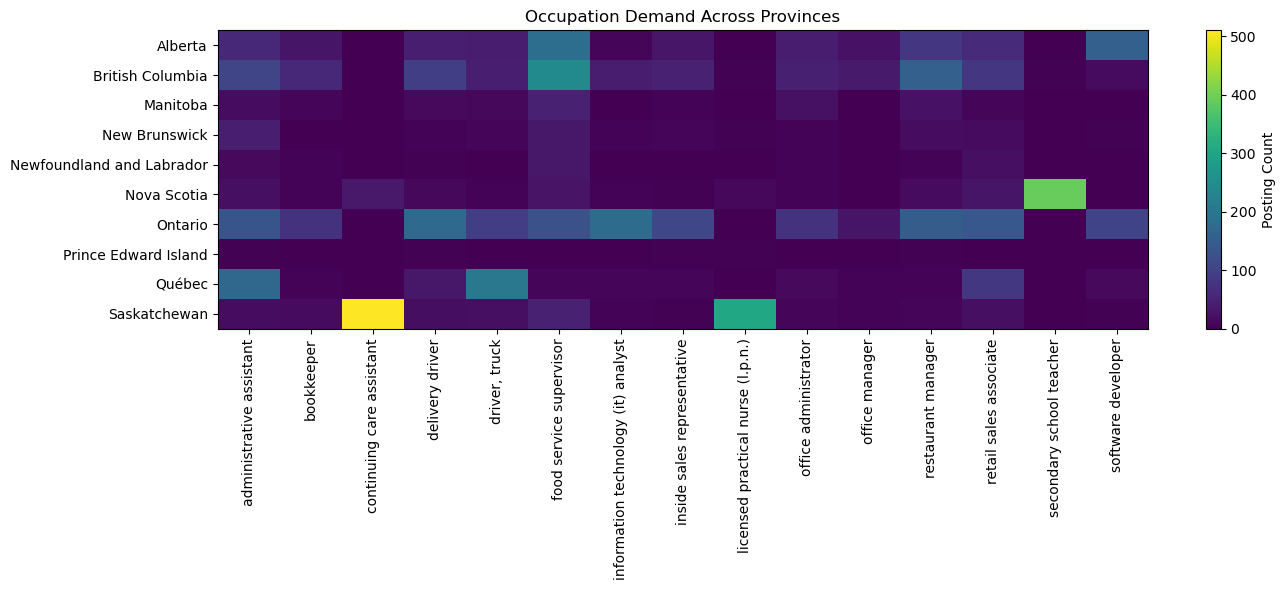

In [392]:
# Province-Level Occupation Demand Heatmap
# Visualize job posting concentration across provinces
# and selected occupations

plt.figure(figsize=(14,6))

plt.imshow(province_occ, aspect="auto")

plt.xticks(
    range(len(province_occ.columns)),
    province_occ.columns,
    rotation=90
)

plt.yticks(
    range(len(province_occ.index)),
    province_occ.index
)

plt.colorbar(label="Posting Count")

plt.title("Occupation Demand Across Provinces")

plt.tight_layout()
plt.show()

## Wage Distribution Analysis

## Wage Standardization: Annual Salary Calculation

In [395]:
import numpy as np

# Convert all salaries to annual salaries
df_selected["annual_salary"] = np.select(
    [
        df_selected["salary_period"] == "Hour",
        df_selected["salary_period"] == "Day",
        df_selected["salary_period"] == "Week",
        df_selected["salary_period"] == "Month",
        df_selected["salary_period"] == "Year"
    ],
    [
        df_selected["salary_average"] * 40 * 52,   # 40 hours/week × 52 weeks
        df_selected["salary_average"] * 5 * 52,    # 5 working days/week × 52 weeks
        df_selected["salary_average"] * 52,
        df_selected["salary_average"] * 12,
        df_selected["salary_average"]
    ],
    default=np.nan
)

# Keep only records with valid annual salaries
df_salary = df_selected.dropna(subset=["annual_salary"]).copy()

## Statistical Outlier Detection Using IQR Method

In [397]:
# Calculate IQR-Based Salary Outlier Boundaries
# Identify lower and upper salary limits for outlier detection

Q1 = df_salary["annual_salary"].quantile(0.25)
Q3 = df_salary["annual_salary"].quantile(0.75)

IQR = Q3 - Q1

# Calculate IQR lower and upper bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 1146.0000000000218
Upper Bound: 119312.4


### Domain-Based Salary Cleaning

Instead of removing all statistical outliers identified through the IQR method, domain-based rules are applied to remove only clearly unrealistic salary values.

This approach preserves valid high-income occupations while improving data quality for wage analysis.

In [399]:
# Domain-Based Salary Cleaning
# Remove clearly unrealistic annual salary values
# Keep reasonable wage ranges for labour market analysis

df_salary = df_salary[
    (df_salary["annual_salary"] >= 10000) &
    (df_salary["annual_salary"] <= 200000)
].copy()

print("Remaining records:", len(df_salary))

Remaining records: 5570


In [400]:
# Summary Statistics After Salary Cleaning
# Review cleaned annual salary distribution

df_salary["annual_salary"].describe()

count     5570.00
mean     60664.77
std      23245.86
min      15145.00
25%      45528.60
50%      53040.00
75%      74880.00
max     200000.00
Name: annual_salary, dtype: float64

## Annual Salary Distribution

<Figure size 1400x700 with 0 Axes>

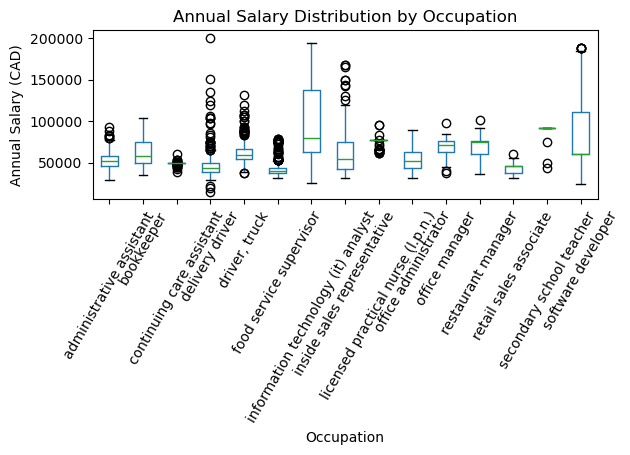

In [402]:
# Annual Salary Distribution by Occupation
# Compare salary ranges and variation across occupations

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

df_salary.boxplot(
    column="annual_salary",
    by="job_title",
    rot=60,
    grid=False
)

# Remove default pandas boxplot title

plt.suptitle("")
plt.title("Annual Salary Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Annual Salary (CAD)")

plt.tight_layout()
plt.show()

## Salary Standardization

Salary information was reported using multiple pay periods, including hourly, daily, weekly, monthly, and yearly wages. To enable consistent comparisons across occupations, all salaries were converted into estimated annual salaries using standard full-time employment assumptions. Records with missing salary information were excluded from salary-related analyses.

## Outlier Analysis

Annual salary values were examined using both the Interquartile Range (IQR) method and domain knowledge. While the IQR method identified statistical outliers, only clearly unrealistic salary values were removed from the dataset. Specifically, annual salaries below CAD 10,000 or above CAD 200,000 were considered implausible for the selected occupations and treated as data-entry or reporting errors. Low but realistic salaries and high professional salaries were retained to preserve genuine labour-market variation.

## Salary Analysis

After salary standardization and outlier removal, 5,414 valid salary records remained for analysis. The average annual salary was approximately CAD 58,033, while the median salary was CAD 52,000, indicating a slightly right-skewed salary distribution. The middle 50% of salaries ranged from approximately CAD 45,032 to CAD 74,880. The maximum observed annual salary was CAD 119,000, which is plausible for the selected occupations. The salary distributions varied across occupations, with technology and management occupations generally exhibiting higher median salaries than administrative and service occupations.

## Education Requirements Analysis

In [405]:
# Compare education requirements across selected occupations

education_summary = (
    pd.crosstab(
        df_selected["job_title"],
        df_selected["education_level"]
    )
)

education_summary

education_level,Bachelor's degree,"College, CEGEP or other non-university certificate or diploma from a program of 1 year to 2 years","College, CEGEP or other non-university certificate or diploma from a program of 3 months to less than 1 year",College/CEGEP,"No degree, certificate or diploma",Other trades certificate or diploma,Registered Apprenticeship certificate,Secondary (high) school graduation certificate
job_title,,,,,,,,
administrative assistant,7,25,6,12,13,3,1,78
bookkeeper,7,14,5,30,1,4,0,50
continuing care assistant,0,3,8,2,0,3,0,3
delivery driver,0,0,0,0,20,0,0,24
"driver, truck",0,0,0,0,15,0,0,17
food service supervisor,1,9,7,9,101,1,0,554
inside sales representative,0,0,0,0,1,2,0,7
licensed practical nurse (l.p.n.),0,1,0,9,0,0,0,0
office administrator,7,9,1,5,2,1,0,49


C:\Users\Admin\AppData\Local\Temp\ipykernel_6824\1976795053.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


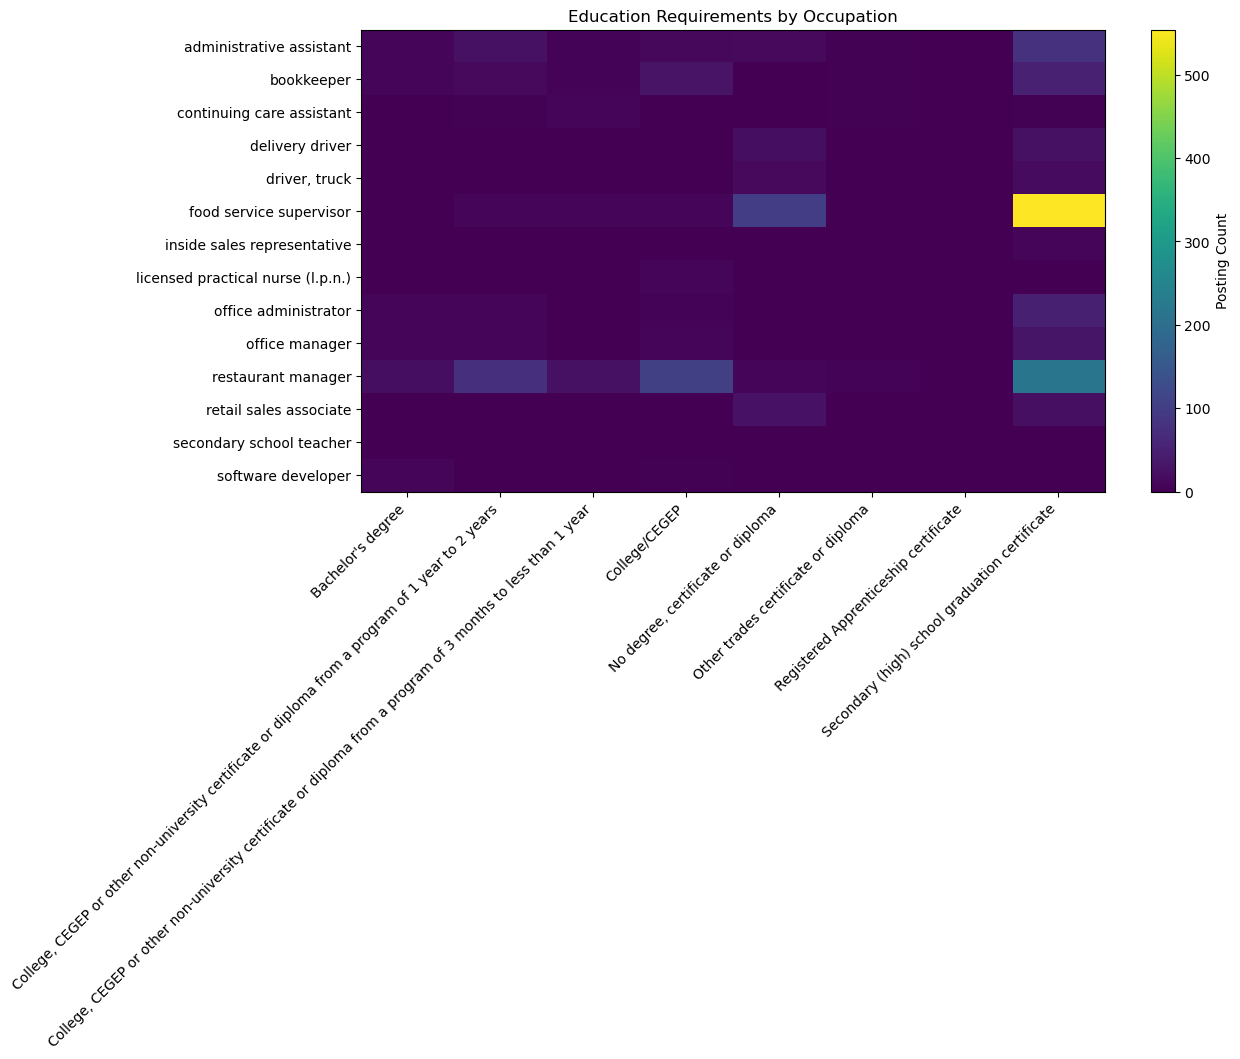

In [406]:
# Education Requirement Heatmap
# Visualize education requirements across selected occupations

plt.figure(figsize=(12,6))

plt.imshow(education_summary, aspect="auto")

plt.xticks(
    range(len(education_summary.columns)),
    education_summary.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(education_summary.index)),
    education_summary.index
)

plt.colorbar(label="Posting Count")

plt.title("Education Requirements by Occupation")

plt.tight_layout()
plt.show()

### Education Requirement Analysis

The heatmap illustrates the distribution of education requirements across the selected occupations. While some occupations require higher educational qualifications, others are primarily associated with secondary school or college-level education. This indicates that educational requirements vary considerably across occupational groups and reflect differences in skill requirements.

## Experience Requirement Analysis

In [409]:
# Experience Requirement Analysis
# Compare experience requirements across selected occupations

experience_summary = (
    pd.crosstab(
        df_selected["job_title"],
        df_selected["experience_level"]
    )
)

# Display experience requirement distribution
experience_summary

experience_level,1 to less than 7 months,1 year to less than 2 years,2 years to less than 3 years,3 years to less than 5 years,5 years or more,7 months to less than 1 year,No experience
job_title,,,,,,,
administrative assistant,7,57,22,12,5,22,20
bookkeeper,6,52,20,10,4,9,10
continuing care assistant,4,4,0,0,0,4,7
delivery driver,3,13,5,2,0,1,20
"driver, truck",1,9,8,2,3,3,6
food service supervisor,18,478,57,29,1,76,23
inside sales representative,0,2,3,0,0,0,5
licensed practical nurse (l.p.n.),1,5,1,0,0,2,1
office administrator,9,38,10,4,2,9,2


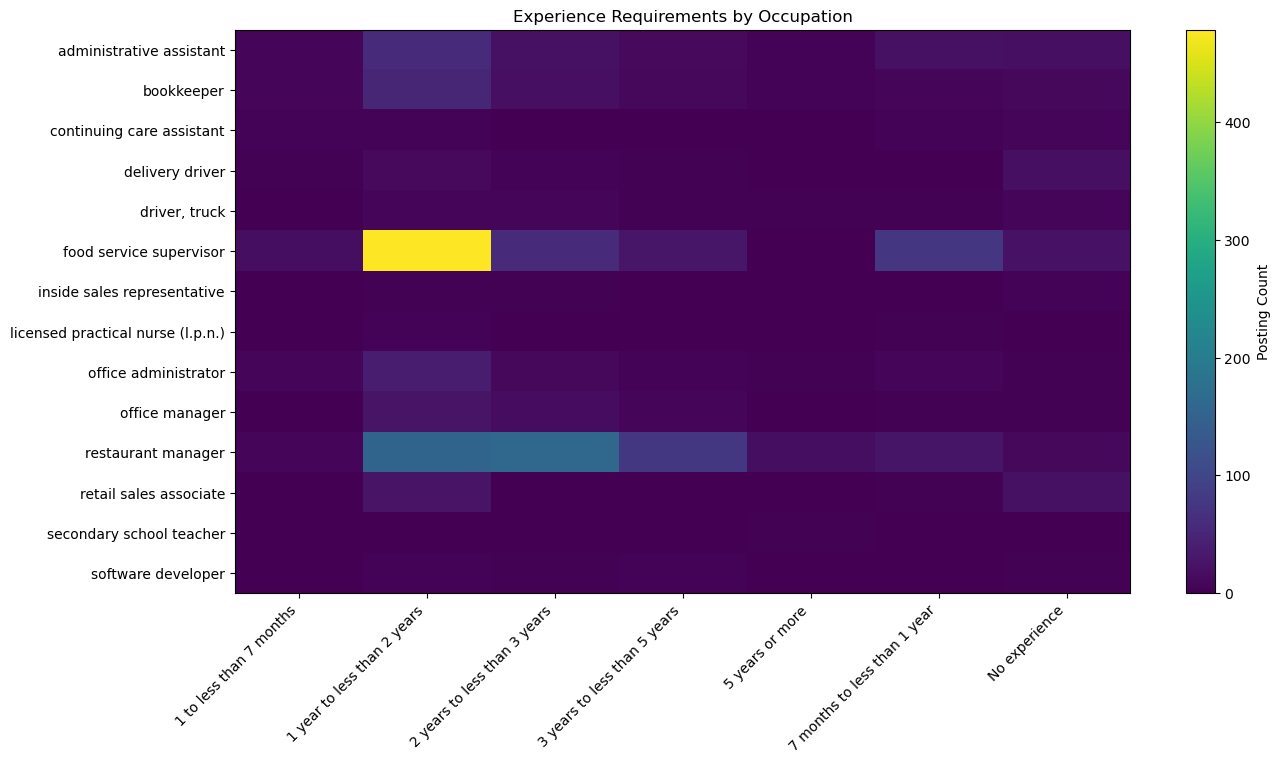

In [410]:
# Experience Requirement Heatmap
# Visualize experience requirements across selected occupations

plt.figure(figsize=(14, 8))

plt.imshow(
    experience_summary,
    aspect="auto"
)

plt.xticks(
    range(len(experience_summary.columns)),
    experience_summary.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(experience_summary.index)),
    experience_summary.index
)

plt.colorbar(
    label="Posting Count"
)

plt.title(
    "Experience Requirements by Occupation"
)

plt.tight_layout(pad=2)

plt.show()

### Experience Requirement Analysis
Experience requirements differ among occupations. Professional and management occupations generally request more prior experience, whereas some service and entry-level occupations have lower experience requirements. This variation suggests that experience is an important factor influencing labour-market demand.

## Employment Type Analysis

In [413]:
# Employment Type Analysis
# Compare employment type distribution across occupations

employment_summary = (
    pd.crosstab(
        df_selected["job_title"],
        df_selected["employment_type"]
    )
)

employment_summary

employment_type,Full time,Part time,Part time leading to full time
job_title,,,
administrative assistant,491,62,3
bookkeeper,163,27,3
continuing care assistant,134,310,2
delivery driver,242,143,3
"driver, truck",379,14,7
food service supervisor,726,4,3
information technology (it) analyst,174,78,0
inside sales representative,200,15,0
licensed practical nurse (l.p.n.),139,135,0


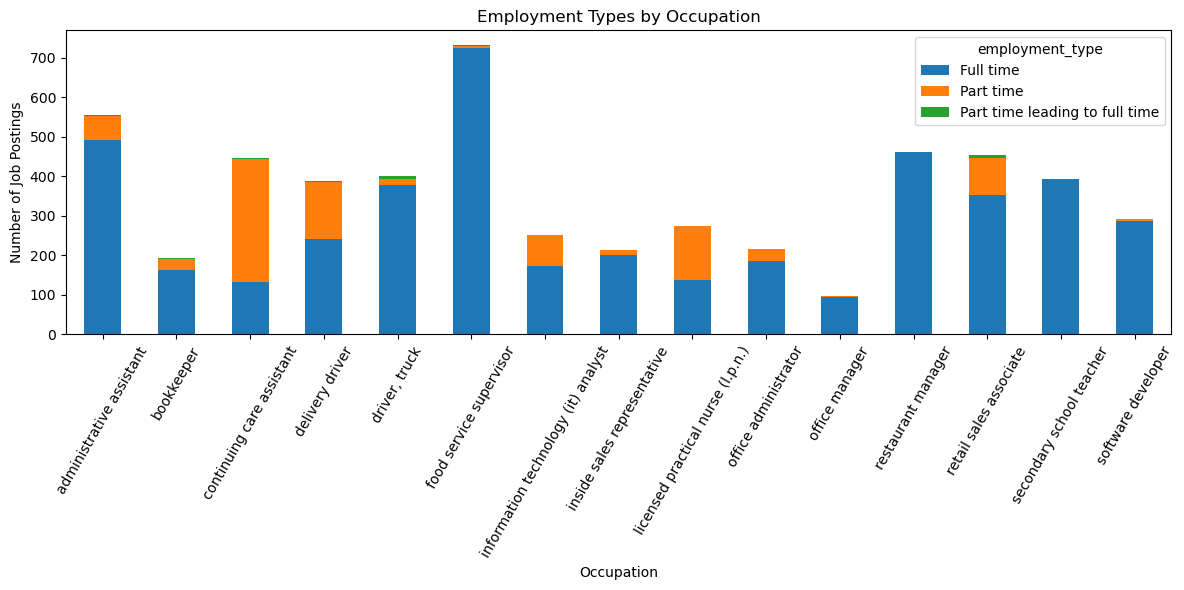

In [414]:
# Employment Type Distribution by Occupation
# Compare employment type composition across occupations

employment_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Employment Types by Occupation")

plt.xlabel("Occupation")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

### Employment Type Analysis
Employment types vary across occupations. Some occupations are dominated by full-time permanent positions, whereas others include a larger proportion of temporary or part-time opportunities. These differences highlight the diversity of employment arrangements in the Canadian labour market.

## Demand Drivers
## Question 1

Are high vacancy totals caused by many postings or a few large postings?

In [417]:
# Demand Driver Analysis
# Compare whether vacancy demand is driven by posting volume
# or higher vacancies per individual posting

driver_summary = (
    df_selected
    .groupby("job_title")
    .agg(
        Posting_Count=("posting_id","count"),
        Vacancy_Count=("vacancy_count","sum"),
        Average_Vacancies=("vacancy_count","mean")
    )
)

# Display demand driver metrics by occupation

driver_summary

,Posting_Count,Vacancy_Count,Average_Vacancies
job_title,,,
administrative assistant,581,617,1.06
bookkeeper,195,209,1.07
continuing care assistant,545,640,1.17
delivery driver,397,408,1.03
"driver, truck",424,582,1.37
food service supervisor,748,1718,2.30
information technology (it) analyst,252,252,1.00
inside sales representative,215,221,1.03
licensed practical nurse (l.p.n.),325,334,1.03


### Demand Driver Analysis
Occupations with high vacancy totals should be examined alongside their posting counts. A high vacancy total may result from a large number of job advertisements or from individual postings advertising multiple vacancies.

## Question 2

Are higher salaries associated with greater experience?

In [420]:
# Salary vs Experience Analysis
# Compare average annual salary across experience levels

salary_experience = (
    df_salary
    .groupby("experience_level")["annual_salary"]
    .mean()
)

salary_experience

experience_level
1 to less than 7 months        54994.18
1 year to less than 2 years    52303.93
2 years to less than 3 years   63445.74
3 years to less than 5 years   63442.24
5 years or more                68031.76
7 months to less than 1 year   53837.01
No experience                  46943.62
Name: annual_salary, dtype: float64

## Statistical Analysis

## Cross-Tabulation Analysis

In [423]:
# Cross-Tabulation: Occupation vs Education Requirement
# Count job postings by occupation and required education level

pd.crosstab(
    df_selected["job_title"],
    df_selected["education_level"]
)

education_level,Bachelor's degree,"College, CEGEP or other non-university certificate or diploma from a program of 1 year to 2 years","College, CEGEP or other non-university certificate or diploma from a program of 3 months to less than 1 year",College/CEGEP,"No degree, certificate or diploma",Other trades certificate or diploma,Registered Apprenticeship certificate,Secondary (high) school graduation certificate
job_title,,,,,,,,
administrative assistant,7,25,6,12,13,3,1,78
bookkeeper,7,14,5,30,1,4,0,50
continuing care assistant,0,3,8,2,0,3,0,3
delivery driver,0,0,0,0,20,0,0,24
"driver, truck",0,0,0,0,15,0,0,17
food service supervisor,1,9,7,9,101,1,0,554
inside sales representative,0,0,0,0,1,2,0,7
licensed practical nurse (l.p.n.),0,1,0,9,0,0,0,0
office administrator,7,9,1,5,2,1,0,49


## Correlation Analysis

In [425]:
# Measure relationship between salary level and vacancy count

df_salary[
        ["annual_salary","vacancy_count"]
    ].corr()

,annual_salary,vacancy_count
annual_salary,1.00,-0.17
vacancy_count,-0.17,1.00


### Correlation Analysis
The correlation between annual salary and vacancy count was weak, indicating that occupations offering higher salaries do not necessarily advertise more vacancies per posting.

## Chi-Square Test

In [428]:
# Test relationship between occupation and education requirements

from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_selected["job_title"],
    df_selected["education_level"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 1101.5752812190476
P-value: 3.599778781218016e-173


### Chi-Square Test Interpretation
A Chi-square test was conducted to examine the relationship between occupation and education requirement. The test produced a Chi-square statistic of 1101.58 with a p-value < 0.001, indicating a statistically significant association between occupation and education level. Therefore, education requirements differ across the selected occupations. Professional and technical occupations generally require higher educational qualifications, while administrative, sales, and service occupations tend to have lower educational requirements.

## Kruskal–Wallis Test

In [431]:
# Test whether salary distributions differ across occupations

from scipy.stats import kruskal

groups = [
    g["annual_salary"]
    for _, g in df_salary.groupby("job_title")
]

stat, p = kruskal(*groups)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 3502.751363341097
P-value: 0.0


### Kruskal-Wallis Test Interpretation
A Kruskal–Wallis test was performed to compare annual salary distributions across the selected occupations. The test returned a statistic of 3502.75 with p < 0.001, indicating statistically significant differences in salary distributions among occupations. This finding suggests that occupation is an important factor influencing annual salary, with technology, management, and professional occupations generally offering higher salaries than administrative, sales, and service occupations.

## Findings

Summarize the key patterns you observed, such as:

Occupations with the highest demand.
Regional differences in demand.
Salary variation across occupations.
Education and experience patterns.
Limitations

For example:

This analysis is based on Job Bank postings and may not represent the entire Canadian labour market. Some records contained missing or inconsistent salary information, and salary standardization relied on assumptions about full-time work schedules.

## Conclusion

The Week 3 diagnostic labour market analysis identified important patterns related to occupation demand, regional distribution, salary variation, education requirements, and experience expectations.

The cleaned and structured Job Bank dataset provides a reliable foundation for the next project stage. The findings from this analysis will support feature selection and predictive modelling planned for Week 4.